In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv("credit_risk_dataset.csv")

In [3]:
df

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4
...,...,...,...,...,...,...,...,...,...,...,...,...
32576,57,53000,MORTGAGE,1.0,PERSONAL,C,5800,13.16,0,0.11,N,30
32577,54,120000,MORTGAGE,4.0,PERSONAL,A,17625,7.49,0,0.15,N,19
32578,65,76000,RENT,3.0,HOMEIMPROVEMENT,B,35000,10.99,1,0.46,N,28
32579,56,150000,MORTGAGE,5.0,PERSONAL,B,15000,11.48,0,0.10,N,26


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ MB


In [5]:
df.shape

(32581, 12)

In [6]:
df.describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32581.000000,3.258100e+04,31686.000000,32581.000000,29465.000000,32581.000000,32581.000000,32581.000000
mean,27.734600,6.607485e+04,4.789686,9589.371106,11.011695,0.218164,0.170203,5.804211
std,6.348078,6.198312e+04,4.142630,6322.086646,3.240459,0.413006,0.106782,4.055001
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,7.920000e+04,7.000000,12200.000000,13.470000,0.000000,0.230000,8.000000
max,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


In [7]:
df.isnull().sum()

person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              895
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3116
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64

### Percentage of missing value

In [8]:
df = pd.read_csv("credit_risk_dataset.csv")
null_percentage = df.isnull().sum() / len(df) * 100
print(null_percentage)

person_age                    0.000000
person_income                 0.000000
person_home_ownership         0.000000
person_emp_length             2.747000
loan_intent                   0.000000
loan_grade                    0.000000
loan_amnt                     0.000000
loan_int_rate                 9.563856
loan_status                   0.000000
loan_percent_income           0.000000
cb_person_default_on_file     0.000000
cb_person_cred_hist_length    0.000000
dtype: float64


### Fill null values with medain

In [9]:
df["person_emp_length"].fillna(df["person_emp_length"].median(),inplace=True)
df["loan_int_rate"].fillna(df["loan_int_rate"].median(),inplace=True)

C:\Users\GORAKH\AppData\Local\Temp\ipykernel_3004\475377497.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["person_emp_length"].fillna(df["person_emp_length"].median(),inplace=True)
C:\Users\GORAKH\AppData\Local\Temp\ipykernel_3004\475377497.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always 

### Check Unique values

In [10]:
df["loan_intent"].unique()

array(['PERSONAL', 'EDUCATION', 'MEDICAL', 'VENTURE', 'HOMEIMPROVEMENT',
       'DEBTCONSOLIDATION'], dtype=object)

In [11]:
df["loan_grade"].unique()

array(['D', 'B', 'C', 'A', 'E', 'F', 'G'], dtype=object)

In [12]:
df["person_home_ownership"].unique()

array(['RENT', 'OWN', 'MORTGAGE', 'OTHER'], dtype=object)

In [13]:
df["person_age"].unique()

array([ 22,  21,  25,  23,  24,  26, 144, 123,  20,  32,  34,  29,  33,
        28,  35,  31,  27,  30,  36,  40,  50,  45,  37,  39,  44,  43,
        41,  46,  38,  47,  42,  48,  49,  58,  65,  51,  53,  66,  61,
        54,  57,  59,  62,  60,  55,  52,  64,  70,  78,  69,  56,  73,
        63,  94,  80,  84,  76,  67], dtype=int64)

In [14]:
df["cb_person_default_on_file"].unique()

array(['Y', 'N'], dtype=object)

In [15]:
df["loan_status"].unique()

array([1, 0], dtype=int64)

In [16]:
df["loan_percent_income"].unique()

array([0.59, 0.1 , 0.57, 0.53, 0.55, 0.25, 0.45, 0.44, 0.42, 0.16, 0.41,
       0.37, 0.32, 0.3 , 0.06, 0.29, 0.31, 0.22, 0.52, 0.14, 0.49, 0.13,
       0.5 , 0.35, 0.17, 0.27, 0.33, 0.08, 0.03, 0.21, 0.63, 0.47, 0.4 ,
       0.07, 0.38, 0.34, 0.04, 0.23, 0.15, 0.11, 0.43, 0.51, 0.02, 0.28,
       0.26, 0.19, 0.39, 0.09, 0.05, 0.61, 0.18, 0.6 , 0.01, 0.48, 0.12,
       0.54, 0.56, 0.46, 0.36, 0.24, 0.2 , 0.72, 0.64, 0.69, 0.77, 0.83,
       0.65, 0.67, 0.58, 0.71, 0.68, 0.7 , 0.66, 0.  , 0.76, 0.62, 0.78])

### check min max Values

In [17]:
max1=df["person_age"].max()
min1=df["person_age"].min()
print(max1)
print(min1)

144
20


In [18]:
max1=df["loan_amnt"].max()
min1=df["loan_amnt"].min()
print(max1)
print(min1)

35000
500


In [19]:
max1=df["person_income"].max()
min2=df["person_income"].min()
print(max1)
print(min2)

6000000
4000


In [20]:
max1=df["cb_person_cred_hist_length"].max()
min1=df["cb_person_cred_hist_length"].min()
print(max1)
print(min1)

30
2


In [21]:
max1=df["person_emp_length"].max()
min1=df["person_emp_length"].min()
print(max1)
print(min1)

123.0
0.0


In [22]:
max1=df["loan_int_rate"].max()
min1=df["loan_int_rate"].min()
print(max1)
print(min1)

23.22
5.42


In [23]:
max1=df["loan_percent_income"].max()
min1=df["loan_percent_income"].min()
print(max1)
print(min1)

0.83
0.0


In [24]:
df["loan_status"].value_counts()

loan_status
0    25473
1     7108
Name: count, dtype: int64

In [25]:
df["loan_grade"].value_counts()

loan_grade
A    10777
B    10451
C     6458
D     3626
E      964
F      241
G       64
Name: count, dtype: int64

### Handling and removing outliers

In [26]:
df = df[df['person_age'] < 80]
df = df[df['person_emp_length'] < 50]


In [27]:
df

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4
5,21,9900,OWN,2.0,VENTURE,A,2500,7.14,1,0.25,N,2
...,...,...,...,...,...,...,...,...,...,...,...,...
32576,57,53000,MORTGAGE,1.0,PERSONAL,C,5800,13.16,0,0.11,N,30
32577,54,120000,MORTGAGE,4.0,PERSONAL,A,17625,7.49,0,0.15,N,19
32578,65,76000,RENT,3.0,HOMEIMPROVEMENT,B,35000,10.99,1,0.46,N,28
32579,56,150000,MORTGAGE,5.0,PERSONAL,B,15000,11.48,0,0.10,N,26


## Univeriate analysis

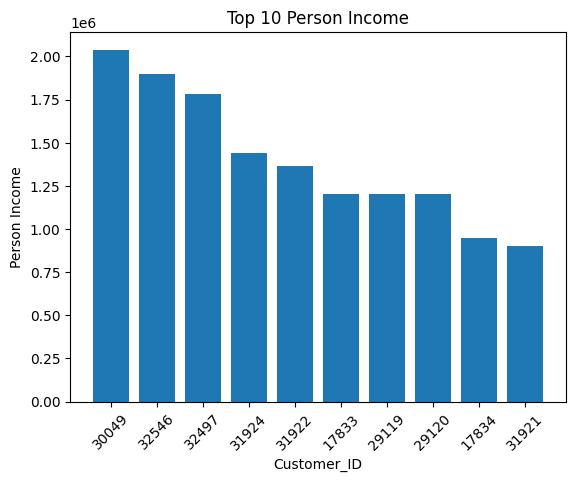

In [28]:
top10 = df.sort_values(by="person_income", ascending=False).head(10)
plt.figure()
plt.bar(top10.index.astype(str), top10["person_income"])
plt.title("Top 10 Person Income")
plt.xlabel("Customer_ID")
plt.ylabel("Person Income")
plt.xticks(rotation=45)
plt.show()

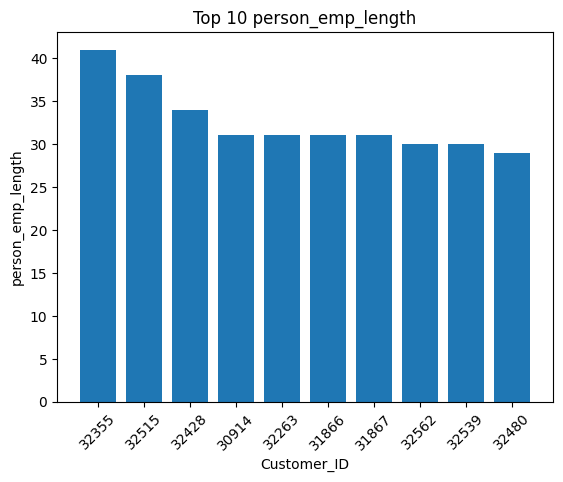

In [29]:
top10 = df.sort_values(by="person_emp_length", ascending=False).head(10)
plt.figure()
plt.bar(top10.index.astype(str), top10["person_emp_length"])
plt.title("Top 10 person_emp_length")
plt.xlabel("Customer_ID")
plt.ylabel("person_emp_length")
plt.xticks(rotation=45)
plt.show()

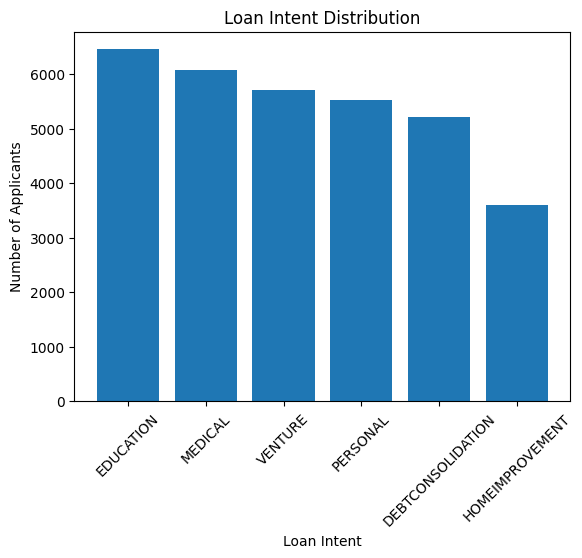

In [30]:
loan_intent_counts = df['loan_intent'].value_counts()
plt.figure()
plt.bar(loan_intent_counts.index, loan_intent_counts.values)
plt.title("Loan Intent Distribution")
plt.xlabel("Loan Intent")
plt.ylabel("Number of Applicants")
plt.xticks(rotation=45)
plt.show()

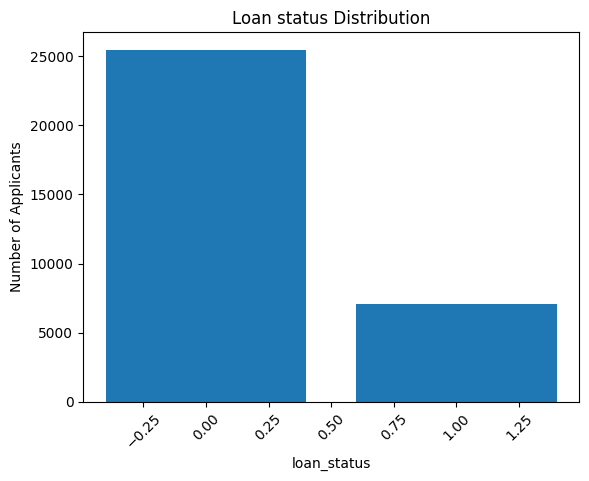

In [31]:
loan_status_counts = df['loan_status'].value_counts()
plt.figure()
plt.bar(loan_status_counts.index, loan_status_counts.values)
plt.title("Loan status Distribution")
plt.xlabel("loan_status")
plt.ylabel("Number of Applicants")
plt.xticks(rotation=45)
plt.show()

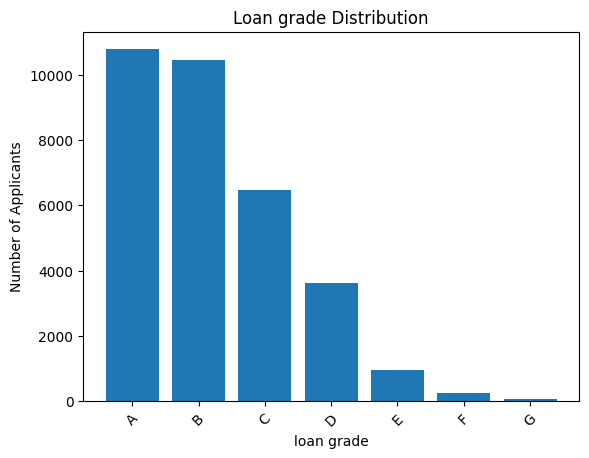

In [32]:
loan_grade_counts = df['loan_grade'].value_counts()
plt.figure()
plt.bar(loan_grade_counts.index, loan_grade_counts.values)
plt.title("Loan grade Distribution")
plt.xlabel("loan grade")
plt.ylabel("Number of Applicants")
plt.xticks(rotation=45)
plt.show()

### Bivariate analysis

In [33]:
income_loan_amt=df.groupby("person_income")["loan_amnt"].mean()
income_loan_amt

person_income
4000        2000.0
4080        1400.0
4200        1975.0
4800        1800.0
4888        1400.0
            ...   
1362000     6600.0
1440000     6400.0
1782000    12025.0
1900000     1500.0
2039784     8450.0
Name: loan_amnt, Length: 4294, dtype: float64

In [34]:
top10 = df.sort_values("person_income", ascending=False).head(10)
top10

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
30049,42,2039784,RENT,0.0,VENTURE,C,8450,12.29,0,0.00,Y,15
32546,60,1900000,MORTGAGE,5.0,PERSONAL,A,1500,10.99,0,0.00,N,21
32497,63,1782000,RENT,13.0,EDUCATION,C,12025,14.27,0,0.01,N,30
31924,44,1440000,MORTGAGE,7.0,DEBTCONSOLIDATION,A,6400,7.40,0,0.00,N,15
31922,47,1362000,MORTGAGE,9.0,VENTURE,A,6600,7.74,0,0.00,N,17
17833,32,1200000,MORTGAGE,1.0,VENTURE,A,12000,7.51,0,0.01,N,8
29119,36,1200000,OWN,16.0,MEDICAL,A,10000,6.54,0,0.01,N,11
29120,40,1200000,MORTGAGE,1.0,MEDICAL,A,10000,10.99,0,0.01,N,16
17834,34,948000,MORTGAGE,18.0,PERSONAL,B,2000,9.99,0,0.00,N,7
31921,37,900000,MORTGAGE,5.0,PERSONAL,C,25000,12.87,0,0.03,Y,13


C:\Users\GORAKH\AppData\Local\Temp\ipykernel_3004\3424375949.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(home_income.values, labels=home_income.index)


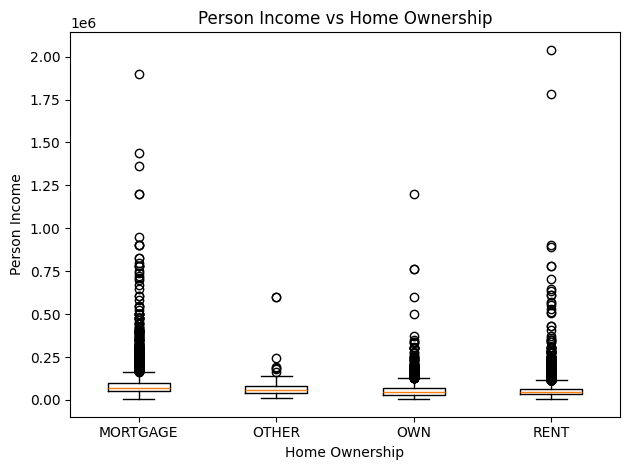

In [35]:
home_income = df.groupby("person_home_ownership")["person_income"].apply(list)
plt.figure()
plt.boxplot(home_income.values, labels=home_income.index)
plt.title("Person Income vs Home Ownership")
plt.xlabel("Home Ownership")
plt.ylabel("Person Income")
plt.tight_layout()
plt.show()

In [36]:
loan_per=df.groupby("loan_amnt")["loan_int_rate"].mean()
loan_per

loan_amnt
500      10.666000
700      12.290000
725       7.370000
750      12.290000
800       7.370000
           ...    
33250    13.060000
33950    11.220000
34000    13.217500
34800    16.770000
35000    12.646141
Name: loan_int_rate, Length: 753, dtype: float64

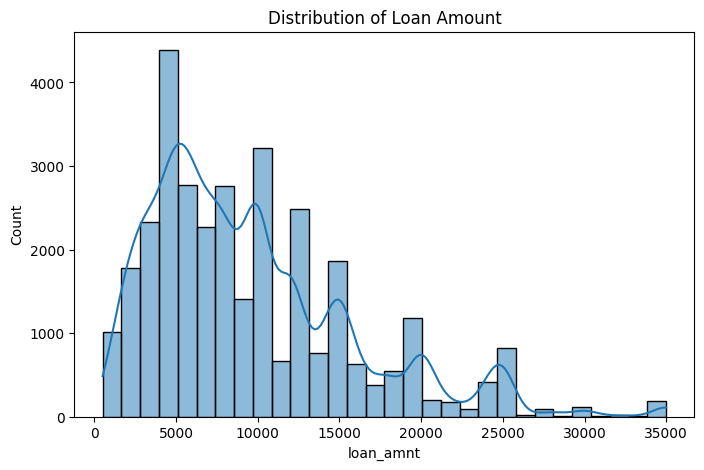

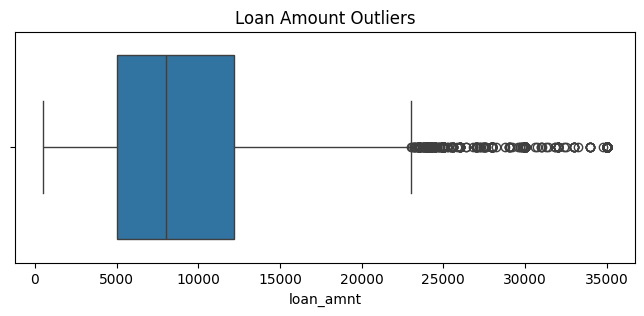

In [37]:
plt.figure(figsize=(8,5))
sns.histplot(df['loan_amnt'], bins=30, kde=True)
plt.title("Distribution of Loan Amount")
plt.show()
plt.figure(figsize=(8,3))
sns.boxplot(x=df['loan_amnt'])
plt.title("Loan Amount Outliers")
plt.show()

In [38]:
df["loan_amnt"].value_counts()

loan_amnt
10000    2663
5000     2042
12000    1809
6000     1800
15000    1502
         ... 
17325       1
9625        1
4525        1
22600       1
29850       1
Name: count, Length: 753, dtype: int64

In [39]:
loan_status=df.groupby("person_income")["loan_status"].sum()
loan_status

person_income
4000       1
4080       1
4200       2
4800       3
4888       1
          ..
1362000    0
1440000    0
1782000    0
1900000    0
2039784    0
Name: loan_status, Length: 4294, dtype: int64

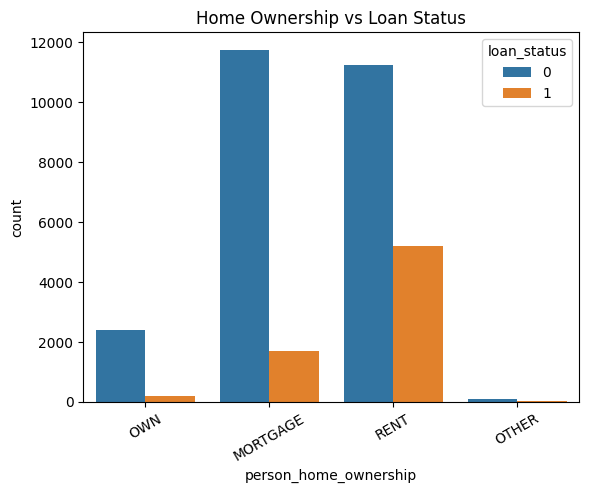

In [40]:
sns.countplot(x='person_home_ownership', hue='loan_status', data=df)
plt.title("Home Ownership vs Loan Status")
plt.xticks(rotation=30)
plt.show()

In [41]:
df["loan_amnt"]

1         1000
2         5500
3        35000
4        35000
5         2500
         ...  
32576     5800
32577    17625
32578    35000
32579    15000
32580     6475
Name: loan_amnt, Length: 32571, dtype: int64

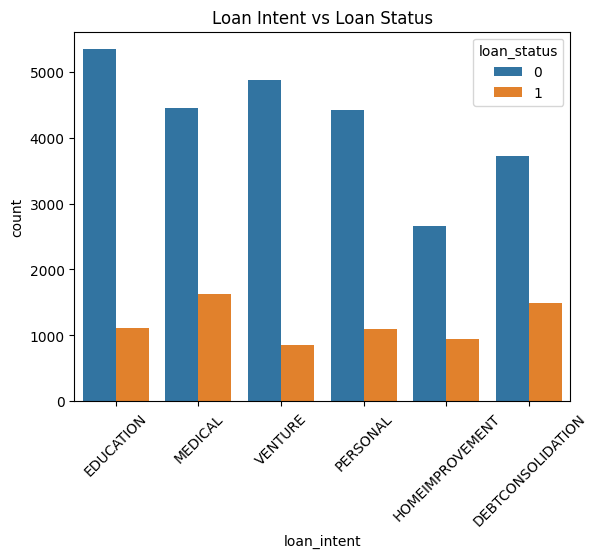

In [42]:
sns.countplot(x='loan_intent', hue='loan_status', data=df)
plt.title("Loan Intent vs Loan Status")
plt.xticks(rotation=45)
plt.show()

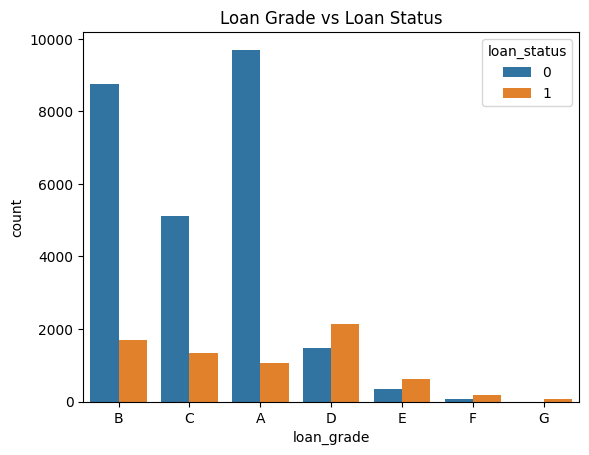

In [43]:
sns.countplot(x='loan_grade', hue='loan_status', data=df)
plt.title("Loan Grade vs Loan Status")
plt.show()

### Correlation

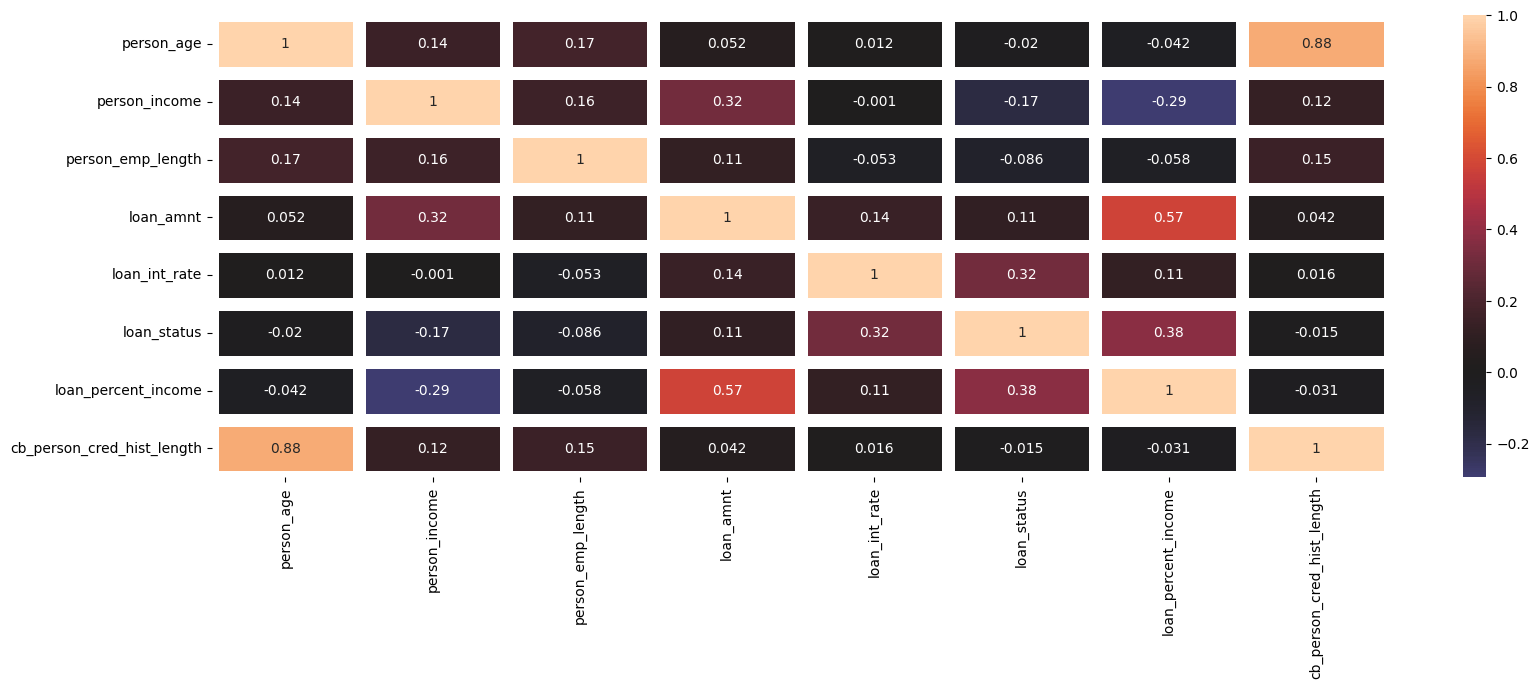

In [44]:

f,ax=plt.subplots(figsize=(19,6))
sns.heatmap(df.corr(numeric_only=True),annot=True,linewidth=8,center=0,ax=ax)
plt.show()

In [45]:
df.isnull().sum()

person_age                    0
person_income                 0
person_home_ownership         0
person_emp_length             0
loan_intent                   0
loan_grade                    0
loan_amnt                     0
loan_int_rate                 0
loan_status                   0
loan_percent_income           0
cb_person_default_on_file     0
cb_person_cred_hist_length    0
dtype: int64

In [46]:
df.to_csv("cleaned_creditdata.csv", index=False)